## Next Steps Learning about Animation

This test animation was 'ripped' from this [geeksforgeeks](https://www.geeksforgeeks.org/matplotlib-animation-funcanimation-class-in-python/) page. As copied it didn't work so it seems like a great test case for learning a little more.

In [ ]:
### Dependencies

In [53]:
#%matplotlib inline

import numpy as np
import matplotlib
from matplotlib import pyplot as plt
from matplotlib import animation
from IPython.display import HTML
matplotlib.rc('animation', html='html5')

from ipywidgets import interact, interactive, widgets
from ipywidgets import Image
from IPython.display import display

### Set up figure for animation

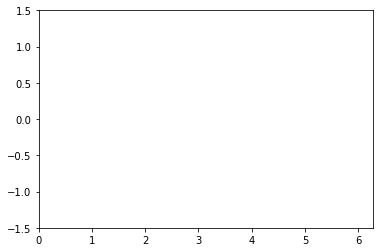

In [2]:
MyFigure, MyAxes = plt.subplots()
MyAxes.set_xlim(( 0, 2*np.pi))
MyAxes.set_ylim((-1.5, 1.5))
MyLine, = MyAxes.plot([], [], lw=2)

### Generate data

In [3]:
x=np.linspace(0,2*np.pi)
AnimationFrames = 100  #total number of frames in animation.
DelayBetweenFrames = 20 #in msec (20 gives 50 fps)
AnimationTime = AnimationFrames * DelayBetweenFrames/1000
print ("The animation will be {:.1f} seconds long.".format(AnimationTime))

The animation will be 2.0 seconds long.


### Animation Function

In [4]:
def a(i):
    y = np.sin(x + 2*np.pi*i/AnimationFrames)
    MyLine.set_data(x, y)
    return (MyLine,)

### Do the animation

In [5]:
MyAnimation = animation.FuncAnimation(MyFigure, a,
                               frames=AnimationFrames, interval=DelayBetweenFrames, blit=True)

### Display the Animation

In [11]:
# Display the animation
HTML(MyAnimation.to_html5_video())

In [12]:
maxx    = 25
stddev  = 10
mtarget =  3.0
btarget =  2.0
maxy    =  1.1*(mtarget*maxx + btarget)

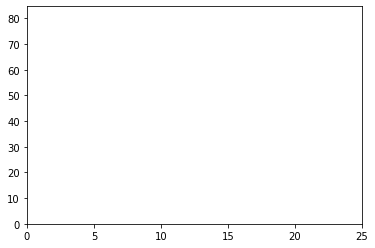

In [18]:
DFFig, DFAxes = plt.subplots()
DFAxes.set_xlim(( 0, maxx))
DFAxes.set_ylim((0, maxy))
DFLineData, = DFAxes.plot([], [], marker='.',    ls='none', mfc=(1,0,0,0),mec=(1,0,0,.25), label='Data')
DFLineFit,  = DFAxes.plot([], [], marker='', ls='-',                                   label='Fit')

In [29]:
AnimationFrames = 100  #total number of frames in animation.
DelayBetweenFrames = 200 #in msec (41.6 gives 24 fps)
MinDataPoints = 2
MaxDataPoints = 1000
NMultiplier = (MaxDataPoints - MinDataPoints)/AnimationFrames
AnimationTime = AnimationFrames * DelayBetweenFrames/1000
print ("The animation will be {:.1f} seconds long.".format(AnimationTime))

The animation will be 20.0 seconds long.


In [40]:
xx=np.linspace(0, maxx)

# this function generates n data points for y values with 'normal noise' around line
def DFData(n):
    x = np.random.uniform(0., maxx, n)
    y = mtarget * x + btarget + np.random.normal(0., stddev, n)
    return (x,y)

def DFAnimator(n):
    n=int(NMultiplier*n + MinDataPoints)
    x,y = DFData(n)
    A = np.vstack([x,np.ones(len(x))]).T
    mfit, bfit = np.linalg.lstsq(A, y, rcond = None)[0]
    DFLineFit.set_data(xx,mfit*xx + bfit)
    DFLineData.set_data(x, y)
    return [DFLineData,DFLineFit]

In [41]:
DFAnim = animation.FuncAnimation(DFFig, DFAnimator ,
                               frames=AnimationFrames, interval=DelayBetweenFrames, blit=False)

In [54]:
# Display the animation
HTML(DFAnim.to_html5_video())

## Interactive Instead of Animation

In [55]:
def DFFigure(n=10):
    x,y = DFData(n)
    A = np.vstack([x,np.ones(n)]).T
    mfit, bfit = np.linalg.lstsq(A, y, rcond=None)[0]
    DFLineFit.set_data(xx,mfit*xx + bfit)
    DFLineData.set_data(x, y)
    display(DFFig)

### Define Widget

In [56]:
DFw=interactive(DFFigure,n=(MinDataPoints,MaxDataPoints),continuous_update=True)

### Display interactive

In [57]:
display(DFw)

interactive(children=(IntSlider(value=10, description='n', max=1000, min=2), Output()), _dom_classes=('widget-…

In [58]:
# define float and int sliders
stddev_widget = widgets.FloatSlider(min=0.05, max=30.0, step=0.05, value=20.0)
n_widget = widgets.IntSlider(min=MinDataPoints,max=MaxDataPoints,step=10,value=(MinDataPoints+MaxDataPoints)/2)

def DFDataTwo(n, sd):
    x = np.random.uniform(0., maxx, n)
    y = mtarget * x + btarget + np.random.normal(0., sd, n)
    return (x,y)

def DFFigure(n, sd):
    x,y = DFDataTwo(n, sd)
    A = np.vstack([x,np.ones(n)]).T
    mfit, bfit = np.linalg.lstsq(A, y, rcond=None)[0]
    DFLineFit.set_data(xx,mfit*xx + bfit)
    DFLineData.set_data(x, y)
    display(DFFig)

DFwnew=interactive(DFFigure,n=n_widget,sd=stddev_widget,continuous_update=True)

In [59]:
display(DFwnew)

interactive(children=(IntSlider(value=501, description='n', max=1000, min=2, step=10), FloatSlider(value=20.0,…